# 6/26 Razor Test 1
### Notes:
Collimitor face to reflection off wedge 95mm  
Wedge to mirror 135mm  
Mirror to lens 142mm  
Lens to blade 66 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (372)                     |   d2: 66    |   Path: 438  

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import signal
from scipy.signal import savgol_filter, medfilt

## Smoothing Algorithms

1. **Moving Average (MA)** — (Codemonk, *Moving Average Filter*)
2. **Exponential Smoothing (SES/EWMA)** — (InfluxData, *Exponential Smoothing Guide*)
3. **Savitzky-Golay (SG)** — (Konstantinovsky, *Savitzky-Golay Filter Guide*)
4. **Median Filter** — (median_filtering reference)
5. **FFT-based denoising** — (Lin et al. 2023, *NIM A* — FFT-based beam profile denoising)

Methods 1-4 applied to the S-curve directly. Method 5 assumes a **Gaussian-shaped, near-zero-at-the-edges**
signal, so we apply the FFT method to the derivative of the S-curve.

In [54]:
# Moving Average Filter is a Finite Impulse Response (FIR) Filter used for smoothing 
# the signal and reducing noise.

# Due to having a fixed window this may be used on both the S-curve and gaussian however 
# edge cases get screwed up.
def simple_moving_average(signal, window=15):
    return np.convolve(signal, np.ones(window)/window, mode='same')

# Making sure to handle edge cases
def moving_average_filter(signal, window=15):
    kernel = np.ones(window) / window
    pad = window // 2
    padded = np.pad(signal, pad, mode='edge')
    smoothed = np.convolve(padded, kernel, mode='same')
    return smoothed[pad:pad + len(signal)]

In [55]:
# Exponential Smoothing / EWMA 
# s(t) = alpha * x(t) + (1 - alpha) * s(t-1)

def exponential_smooth(signal, alpha=None):
    model = SimpleExpSmoothing(signal, initialization_method="estimated")
    fit = model.fit(smoothing_level=alpha, optimized=(alpha is None))
    return fit.fittedvalues, fit.params['smoothing_level']

In [56]:
# Savitzky-Golay Filter
# Fits a polynomial to each window by least squares.
# Window needs to be an odd number.

def sg_smooth(signal, window_length=25, polyorder=3):
    if window_length % 2 == 0:
        window_length += 1
    return savgol_filter(signal, window_length=window_length, polyorder=polyorder)

In [57]:
# Median Filter
# Each point is replaced by the median of an odd-sized neighborhood window.
def median_smooth(signal, window=9):
    if window % 2 == 0:
        window += 1
    return medfilt(signal, kernel_size=window)

In [58]:
# FFT-based denoising (Lin, Tan, Li, Wang & Shen, 2023, NIM A 1047:167781)
# I.   FFT the (uniformly resampled) signal, shift zero-frequency to center.
# II.  Estimate the low-frequency Gaussian width sigma_lf from the magnitude
#      spectrum's FWHM, and discard all frequency content beyond 4*sigma_lf.
# III. Within the retained band, drop any remaining low-amplitude components
#      below a noise threshold 3*sigma_hf*sqrt(2*log10(N)), where sigma_hf is
#      std. of the amplitudes in the discarded high-frequency band.
# IV.  Inverse FFT back to the spatial domain.
# This assumes evenly-spaced samples and a Gaussian signal.
def sigma_lf_fwhm(freqs, magnitude):
    """Half-width-at-half-max of the magnitude spectrum around its center bin."""
    center_index = len(freqs) // 2
    peak = magnitude[center_index]
    half_max = peak / 2
    right_index = center_index
    while right_index < len(freqs) - 1 and magnitude[right_index] > half_max:
        right_index += 1
    if right_index > center_index:
        f0, f1 = freqs[right_index - 1], freqs[right_index]
        m0, m1 = magnitude[right_index - 1], magnitude[right_index]
        f_half = f0 + (half_max - m0) * (f1 - f0) / (m1 - m0) if m1 != m0 else f1
    else:
        f_half = freqs[right_index]
    fwhm = 2 * abs(f_half - freqs[center_index])
    return fwhm / 2.355  # FWHM -> sigma for a Gaussian

def fft_denoise_profile(x_raw, profile_raw):
    n = len(x_raw)
    x_uniform = np.linspace(x_raw.min(), x_raw.max(), n)
    # FFT needs even spacing and linear interpolation should be fine following that it 
    # should regester as high frequency noise and get filtered out.
    p_uniform = np.interp(x_uniform, x_raw, profile_raw)
    dx = x_uniform[1] - x_uniform[0]

    spectrum = np.fft.fftshift(np.fft.fft(p_uniform))
    freqs = np.fft.fftshift(np.fft.fftfreq(n, d=dx))
    magnitude = np.abs(spectrum)

    sigma_lf = sigma_lf_fwhm(freqs, magnitude)                                      # Step I / II
    lf_mask = np.abs(freqs) <= 4 * sigma_lf
    spectrum_filtered = spectrum * lf_mask

    hf_magnatudes = magnitude[~lf_mask]                                             # Step III
    sigma_hf = np.std(hf_magnatudes)
    N = len(hf_magnatudes)
    threshold = 3 * sigma_hf * np.sqrt(2 * np.log10(N))
    spectrum_filtered[np.abs(spectrum_filtered) < threshold] = 0

    denoised_uniform = np.real(np.fft.ifft(np.fft.ifftshift(spectrum_filtered)))    # Step IV
    denoised = np.interp(x_raw, x_uniform, denoised_uniform)
    return denoised, sigma_lf, freqs, magnitude, lf_mask

In [59]:
df = pd.read_csv('data/razor_data.csv')
df['Power (mW)'] = pd.to_numeric(df['Power (mW)'])
df['Distance (mm)'] = pd.to_numeric(df['Distance (mm)'])
df_clean = df.dropna().copy()

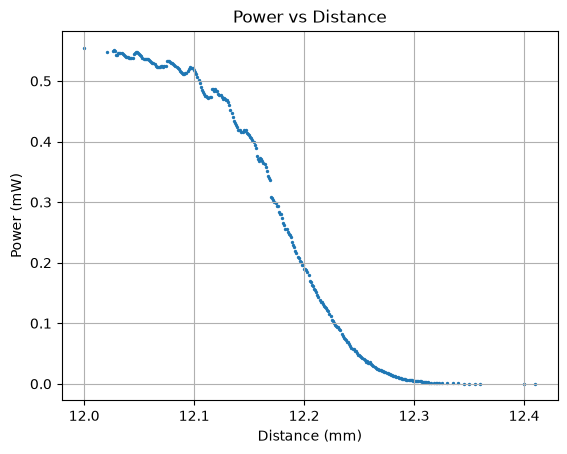

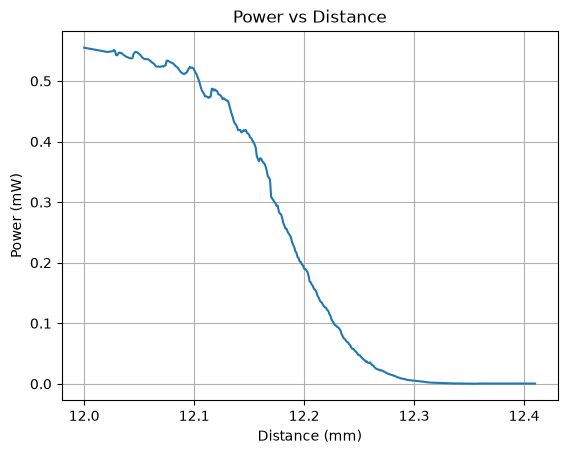

In [60]:
plt.scatter(df_clean['Distance (mm)'], df_clean['Power (mW)'], s=2)

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)
plt.show()

plt.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'])

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()



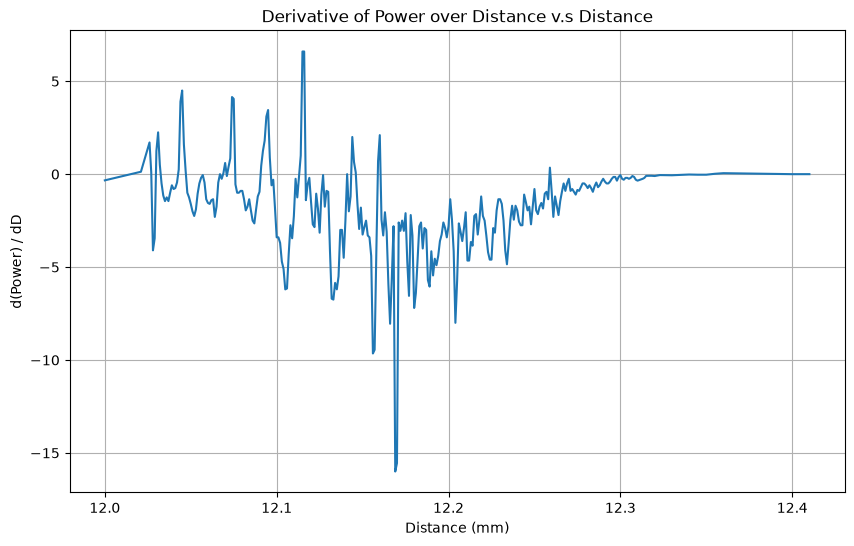

In [61]:
df_clean = df_clean.sort_values('Distance (mm)').reset_index(drop=True)

df_clean['Derivative'] = np.gradient(df_clean['Power (mW)'], df_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df_clean['Distance (mm)'], df_clean['Derivative'])

plt.title('Derivative of Power over Distance v.s Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / dD')
plt.grid(True)

plt.show()

In [62]:
df_clean = df.dropna().sort_values('Distance (mm)').reset_index(drop=True)
# The first k-1 values will result in NaN.
window = 5
rolling_median = df_clean['Power (mW)'].rolling(window=window, center=True).median()
df_clean = df_clean.dropna().reset_index(drop=True)

x1 = df_clean['Distance (mm)'].values
y1 = df_clean['Power (mW)'].values

In [63]:
def exponential_smooth(signal, alpha=0.25):
    smoothed = pd.Series(signal).ewm(alpha=alpha, adjust=False).mean().values
    return smoothed, alpha

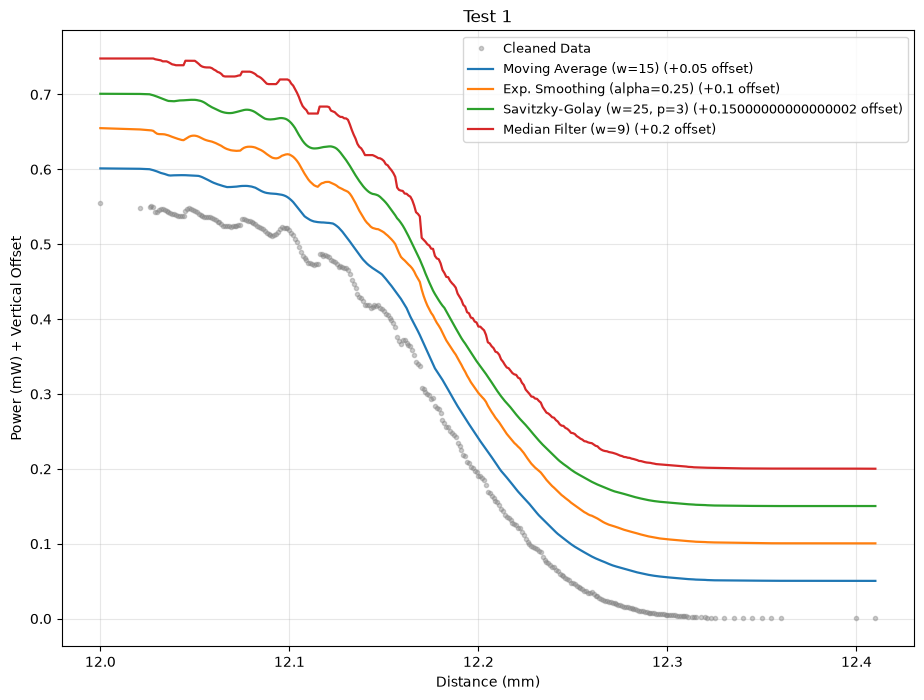

In [64]:
ma1 = moving_average_filter(y1, window=15)
es1, alpha1 = exponential_smooth(y1, alpha=0.25)
sg1 = sg_smooth(y1, window_length=25, polyorder=3)
med1 = median_smooth(y1, window=9)

scurve_methods_1 = {
    'Moving Average (w=15)': ma1,
    f'Exp. Smoothing (alpha={alpha1:.2f})': es1,
    'Savitzky-Golay (w=25, p=3)': sg1,
    'Median Filter (w=9)': med1,
}

plt.figure(figsize=(11, 8))
plt.plot(x1, y1, '.', color='grey', alpha=0.4, label='Cleaned Data')
offset_step = 0.05 
for i, (name, sig) in enumerate(scurve_methods_1.items()):
    current_offset = (i + 1) * offset_step
    plt.plot(x1, sig + current_offset, linewidth=1.6, label=f"{name} (+{current_offset} offset)")
plt.title('Test 1')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW) + Vertical Offset')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

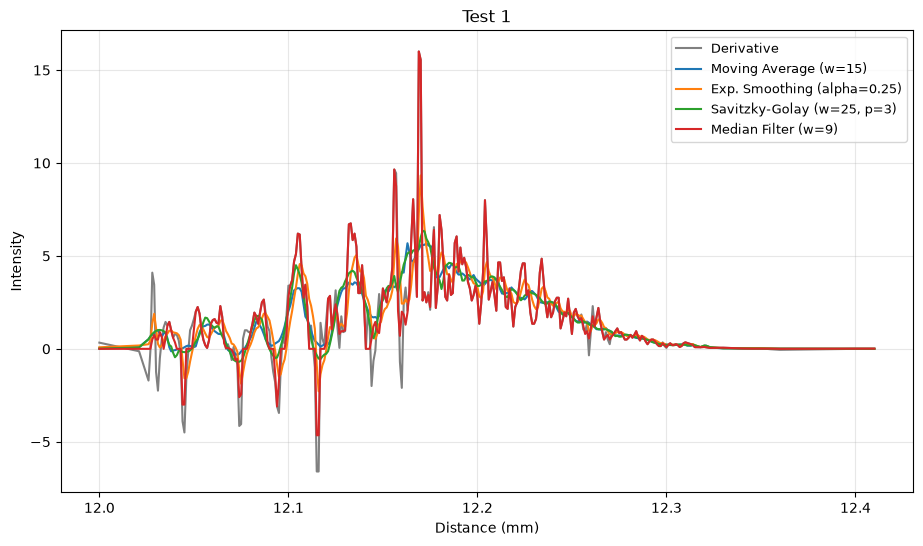

In [65]:
raw_profile_1 = -np.gradient(y1, x1)

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, color='grey', label='Derivative')
for name, sig in scurve_methods_1.items():
    prof = -np.gradient(sig, x1)
    plt.plot(x1, prof, label=name)
plt.title('Test 1')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

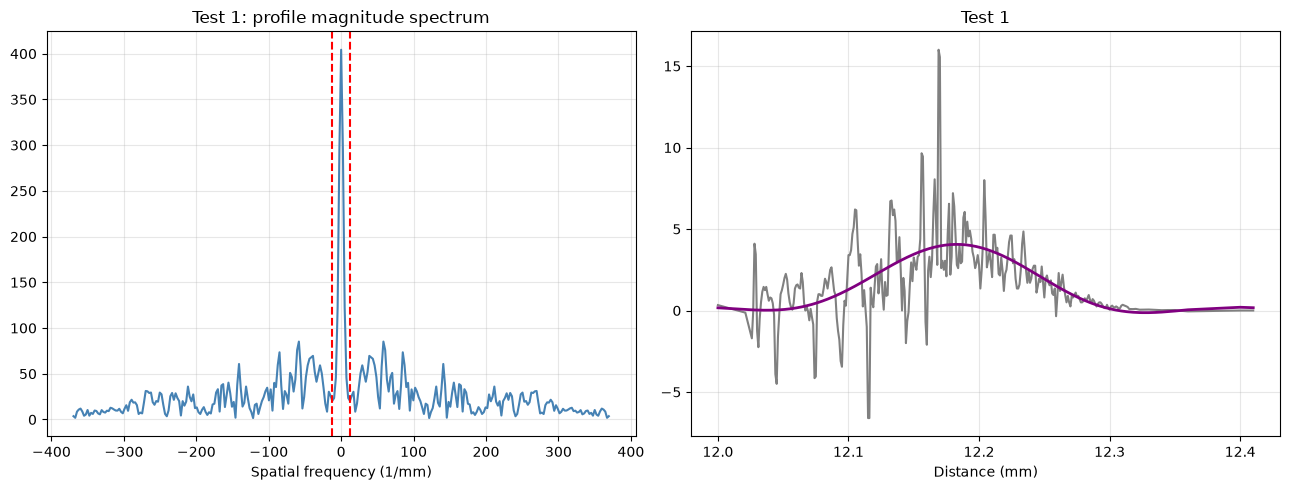

In [66]:
fft_profile_1, sigma_lf_1, freqs_1, mag_1, lf_mask_1 = fft_denoise_profile(x1, raw_profile_1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_1, mag_1, color='steelblue')
axes[0].axvline(4 * sigma_lf_1, color='red', linestyle='--')
axes[0].axvline(-4 * sigma_lf_1, color='red', linestyle='--')
axes[0].set_title('Test 1: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].grid(alpha=0.3)

axes[1].plot(x1, raw_profile_1, color='grey', label='Derivative')
axes[1].plot(x1, fft_profile_1, color='purple', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 1')
axes[1].set_xlabel('Distance (mm)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

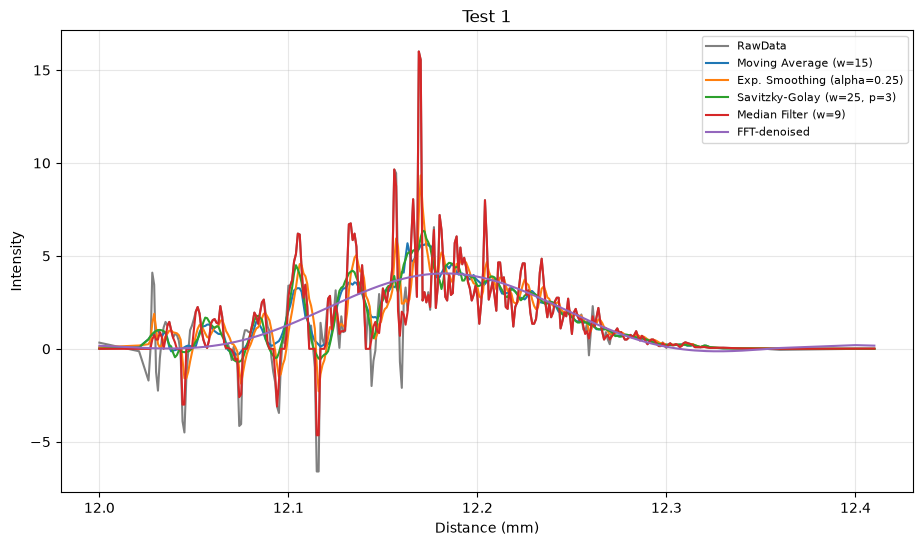

In [67]:
all_profiles_1 = {name: -np.gradient(sig, x1) for name, sig in scurve_methods_1.items()}
all_profiles_1['FFT-denoised'] = fft_profile_1

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, color='grey', label='RawData')
for name, prof in all_profiles_1.items():
    plt.plot(x1, prof, label=name)
plt.title('Test 1')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()


In [68]:
def gaussian_beam(x, A, x0, w, offset):
    return A * np.exp(-2 * (x - x0) ** 2 / w ** 2) + offset

def fit_beam_radius(x, profile):
    center_guess = np.average(x, weights=profile)
    variance_guess = np.average((x - center_guess)**2, weights=profile)
    std_guess = np.sqrt(variance_guess)
    w_guess = 2 * std_guess
    p0 = [profile.max(), center_guess, w_guess, 0]
    popt, pcov = curve_fit(gaussian_beam, x, profile, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

Method              w (1/e^2 radius, um)     center (mm)
Moving Average             88.79 +/-  3.13         12.1824
Exp. Smoothing             87.91 +/-  5.16         12.1854
Savitzky-Golay             88.25 +/-  4.20         12.1824
Median Filter              89.18 +/-  8.84         12.1824
FFT-denoised              111.99 +/-  0.54         12.1821


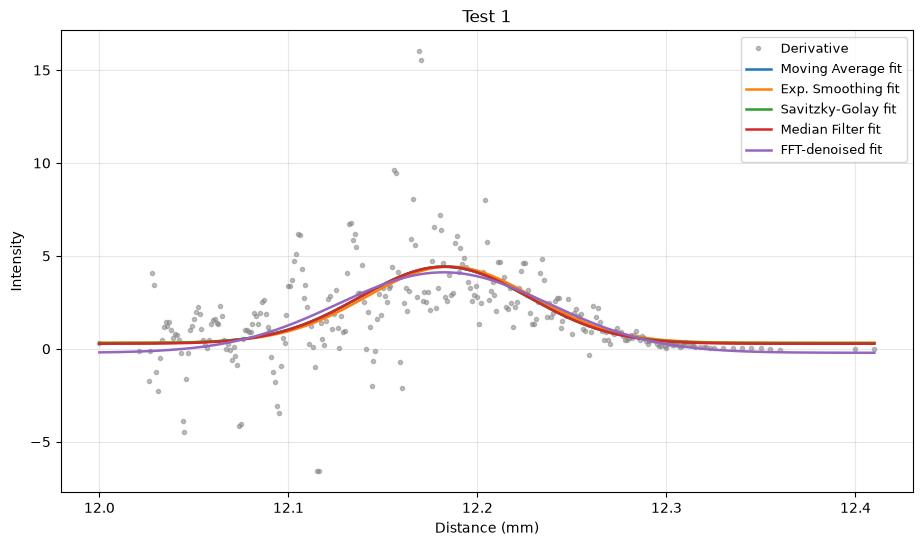

In [69]:
profiles_1 = {
    'Moving Average': -np.gradient(ma1, x1),
    'Exp. Smoothing': -np.gradient(es1, x1),
    'Savitzky-Golay': -np.gradient(sg1, x1),
    'Median Filter': -np.gradient(med1, x1),
    'FFT-denoised': fft_profile_1,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_1 = {}
for name, prof in profiles_1.items():
    popt, perr = fit_beam_radius(x1, prof)
    A, x0, w, off = popt
    fits_1[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x1, raw_profile_1, '.', color='grey', alpha=0.5, label='Derivative')
x1_fine = np.linspace(x1.min(), x1.max(), 500)
for name, popt in fits_1.items():
    plt.plot(x1_fine, gaussian_beam(x1_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 1')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# 6/29 Razor Test 2
### Notes:
Collimitor face to reflection off wedge 85mm  
Wedge to mirror 133mm  
Mirror to lens 102.5mm  
Lens to blade 56 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (320.5)                   |   d2: 56    |   Path: 376.5  

In [70]:
df2 = pd.read_csv('data/razor_data2.csv')
df2['Power (mW)'] = pd.to_numeric(df2['Power (mW)'])
df2['Distance (mm)'] = pd.to_numeric(df2['Distance (mm)'])
df2_clean = df2.dropna().copy()

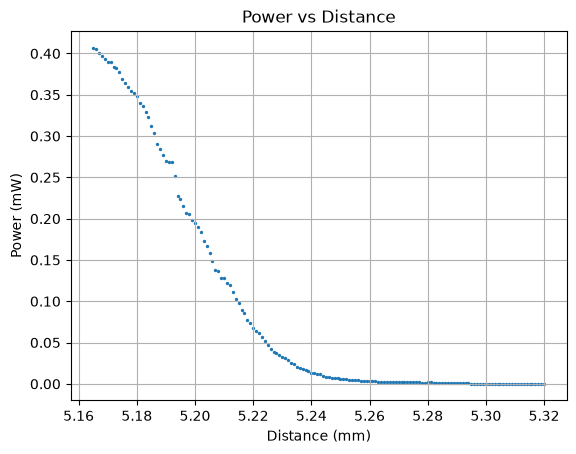

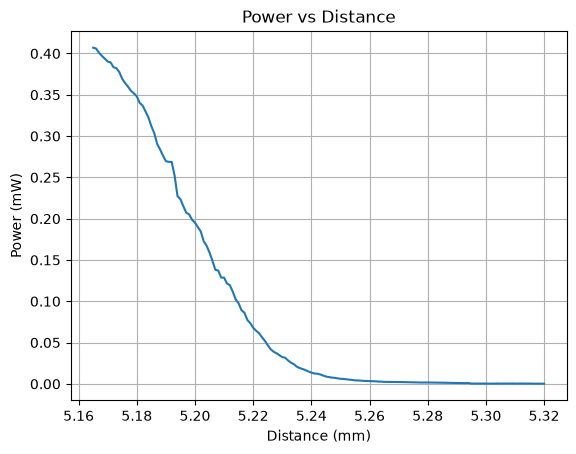

In [71]:
plt.scatter(df2_clean['Distance (mm)'], df2_clean['Power (mW)'],s=2)

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

plt.plot(df2_clean['Distance (mm)'], df2_clean['Power (mW)'])

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

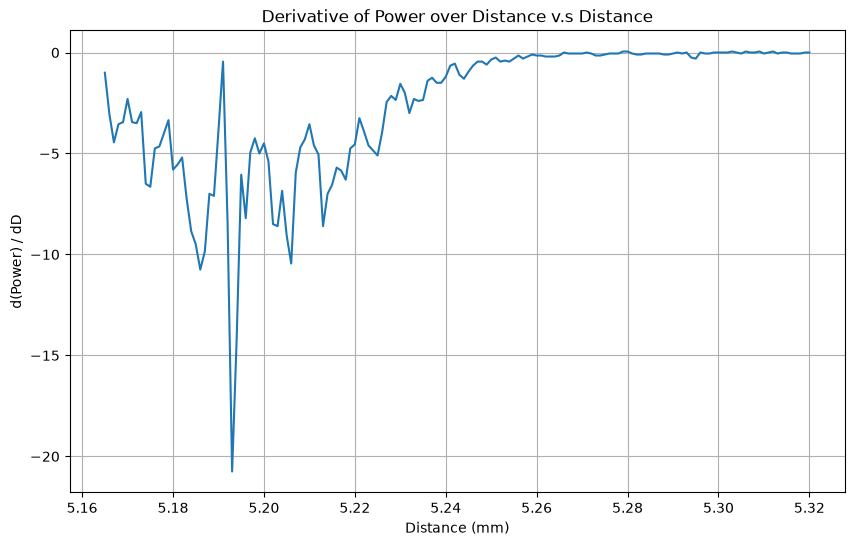

In [72]:
df2_clean = df2_clean.sort_values('Distance (mm)').reset_index(drop=True)

df2_clean['Derivative'] = np.gradient(df2_clean['Power (mW)'], df2_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df2_clean['Distance (mm)'], df2_clean['Derivative'])

plt.title('Derivative of Power over Distance v.s Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / dD')
plt.grid(True)

plt.show()

In [73]:
df2_clean = df2.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df2_clean['Power (mW)'].rolling(window=window, center=True).median()
df2_clean = df2_clean.dropna().reset_index(drop=True)

x2 = df2_clean['Distance (mm)'].values
y2 = df2_clean['Power (mW)'].values

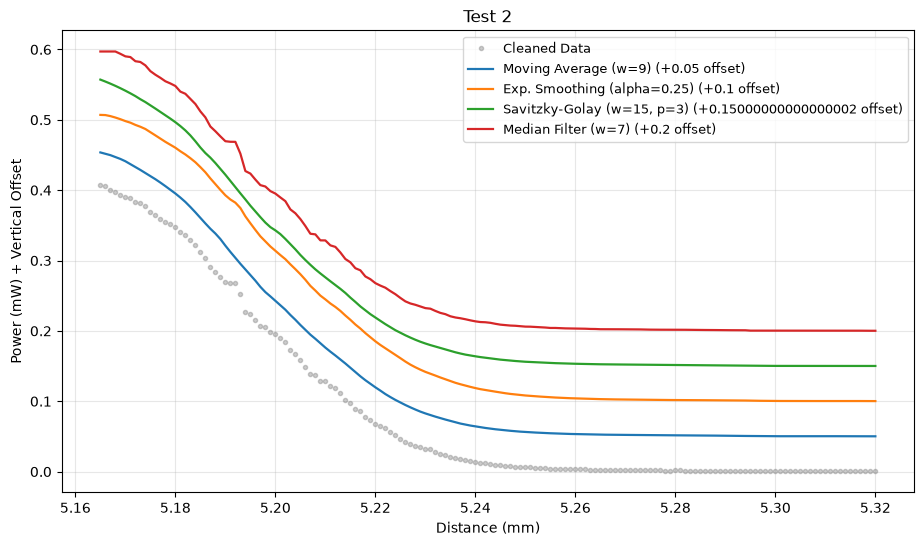

In [74]:
ma2 = moving_average_filter(y2, window=9)
es2, alpha2 = exponential_smooth(y2, alpha=0.25)
sg2 = sg_smooth(y2, window_length=15, polyorder=3)
med2 = median_smooth(y2, window=7)

scurve_methods_2 = {
    'Moving Average (w=9)': ma2,
    f'Exp. Smoothing (alpha={alpha2:.2f})': es2,
    'Savitzky-Golay (w=15, p=3)': sg2,
    'Median Filter (w=7)': med2,
}

plt.figure(figsize=(11, 6))
plt.plot(x2, y2, '.', color='grey', alpha=0.4, label='Cleaned Data')
offset_step = 0.05 
for i, (name, sig) in enumerate(scurve_methods_2.items()):
    current_offset = (i + 1) * offset_step
    plt.plot(x2, sig + current_offset, linewidth=1.6, label=f"{name} (+{current_offset} offset)")

plt.title('Test 2')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW) + Vertical Offset')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

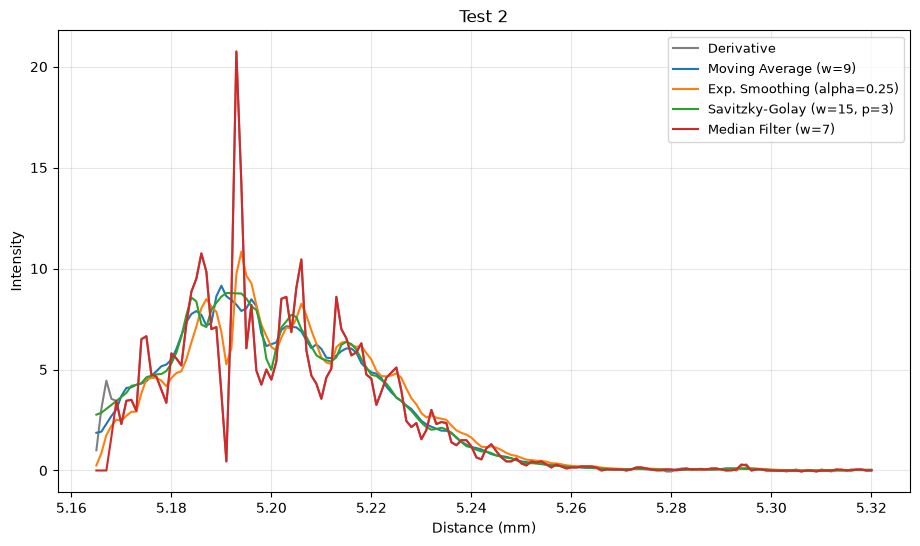

In [75]:
raw_profile_2 = -np.gradient(y2, x2)

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, color='grey', label='Derivative')
for name, sig in scurve_methods_2.items():
    prof = -np.gradient(sig, x2)
    plt.plot(x2, prof, label=name)
plt.title('Test 2')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

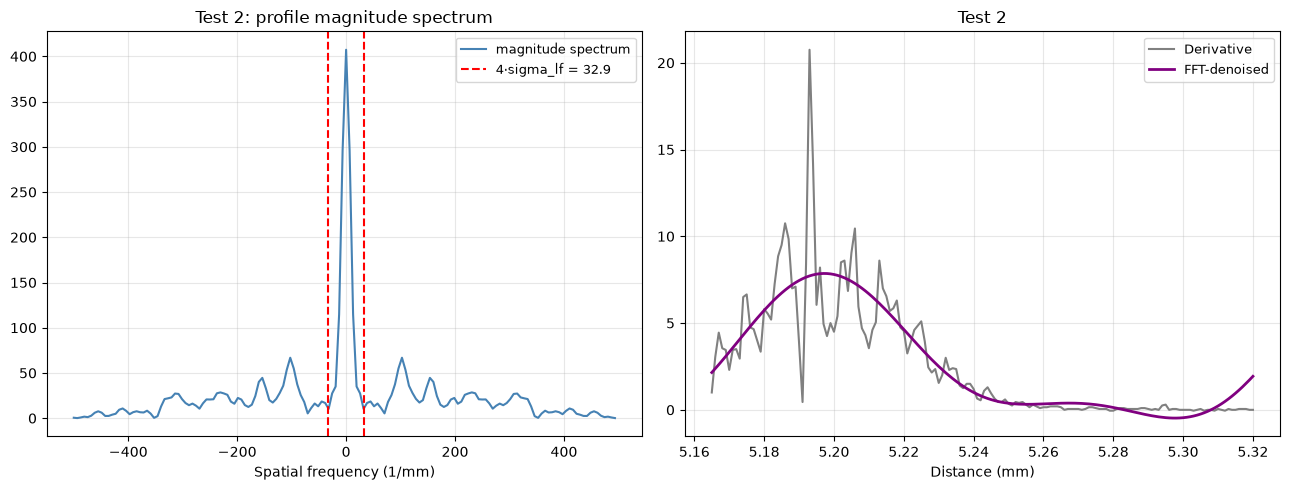

In [76]:
fft_profile_2, sigma_lf_2, freqs_2, mag_2, lf_mask_2 = fft_denoise_profile(x2, raw_profile_2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_2, mag_2, color='steelblue', label='magnitude spectrum')
axes[0].axvline(4 * sigma_lf_2, color='red', linestyle='--', label=f'4·sigma_lf = {4*sigma_lf_2:.1f}')
axes[0].axvline(-4 * sigma_lf_2, color='red', linestyle='--')
axes[0].set_title('Test 2: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(x2, raw_profile_2, color='grey', label='Derivative')
axes[1].plot(x2, fft_profile_2, color='purple', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 2')
axes[1].set_xlabel('Distance (mm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

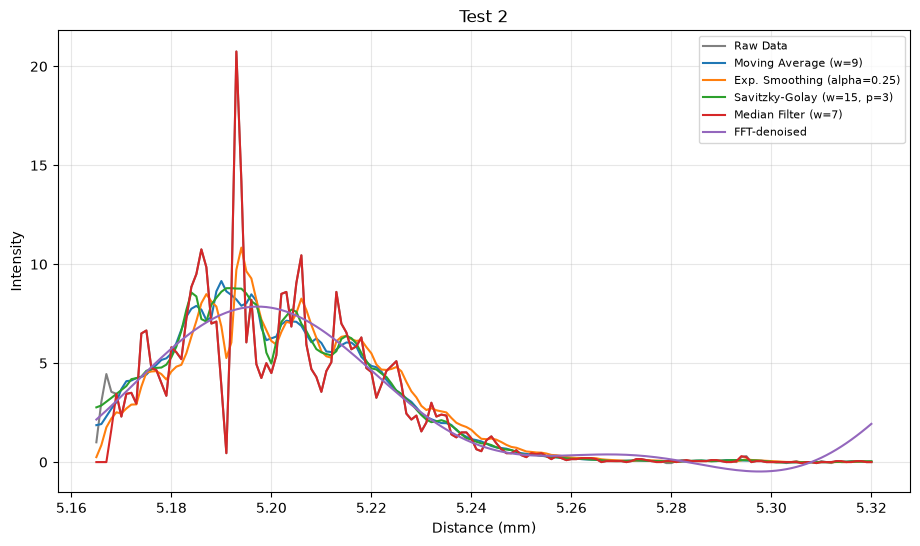

In [77]:
all_profiles_2 = {name: -np.gradient(sig, x2) for name, sig in scurve_methods_2.items()}
all_profiles_2['FFT-denoised'] = fft_profile_2

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, color='grey', label='Raw Data')
for name, prof in all_profiles_2.items():
    plt.plot(x2, prof, label=name)
plt.title('Test 2')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

Method              w (1/e^2 radius, um)     center (mm)
Moving Average             43.91 +/-  0.76          5.1968
Exp. Smoothing             43.19 +/-  1.13          5.2001
Savitzky-Golay             44.56 +/-  0.94          5.1964
Median Filter              41.69 +/-  2.83          5.1975
FFT-denoised               41.69 +/-  0.57          5.1976


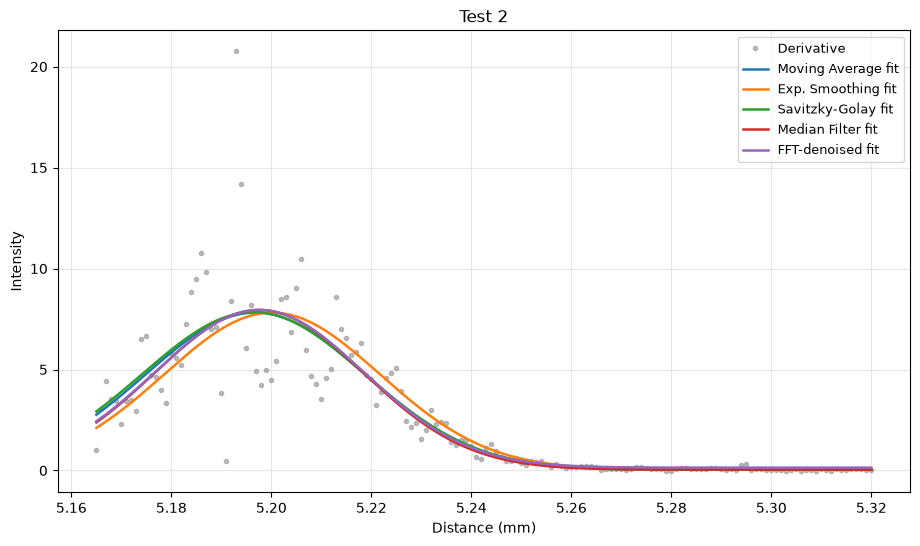

In [78]:
profiles_2 = {
    'Moving Average': -np.gradient(ma2, x2),
    'Exp. Smoothing': -np.gradient(es2, x2),
    'Savitzky-Golay': -np.gradient(sg2, x2),
    'Median Filter': -np.gradient(med2, x2),
    'FFT-denoised': fft_profile_2,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_2 = {}
for name, prof in profiles_2.items():
    popt, perr = fit_beam_radius(x2, prof)
    A, x0, w, off = popt
    fits_2[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x2, raw_profile_2, '.', color='grey', alpha=0.5, label='Derivative')
x2_fine = np.linspace(x2.min(), x2.max(), 500)
for name, popt in fits_2.items():
    plt.plot(x2_fine, gaussian_beam(x2_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 2')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# Razor Test 3
### Notes:
Collimitor face to reflection off wedge 85mm  
Wedge to mirror 133mm  
Mirror to lens 102.5mm  
Lens to blade 56 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (320.5)                   |   d2: 56    |   Path: 376.5  

In [79]:
df3 = pd.read_csv('data/razor_data3.csv')
df3['Power (mW)'] = pd.to_numeric(df3['Power (mW)'])
df3['Distance (mm)'] = pd.to_numeric(df3['Distance (mm)'])
df3['Ambient power'] = pd.to_numeric(df3['Ambient power'])
df3_clean = df3.dropna().copy()

df3_f = pd.read_csv('data/razor_data3.csv')
df3_f['Distance (mm)'] = pd.to_numeric(df3_f['Distance (mm)'])
df3_f['Ambient power'] = pd.to_numeric(df3_f['Ambient power'])
df3_f['Power (mW) filtered'] = pd.to_numeric(df3_f['Power (mW)  filtered'])
df3_clean_f = df3_f.dropna().copy()

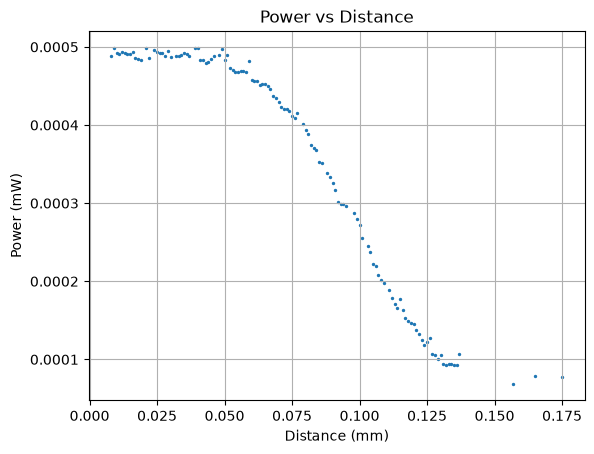

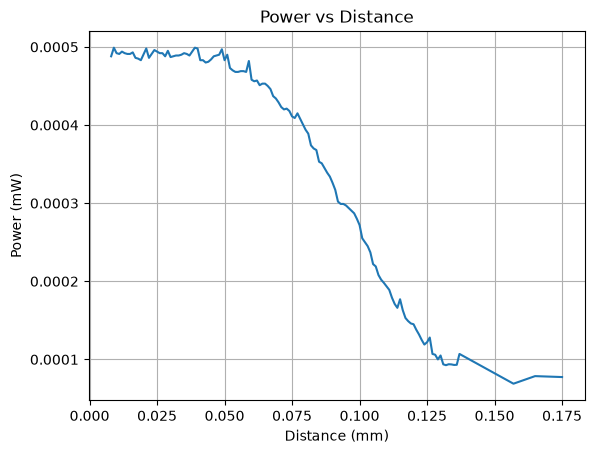

In [80]:
plt.scatter(df3_clean['Distance (mm)'], df3_clean['Power (mW)'],s=2)

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

plt.plot(df3_clean['Distance (mm)'], df3_clean['Power (mW)'])

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

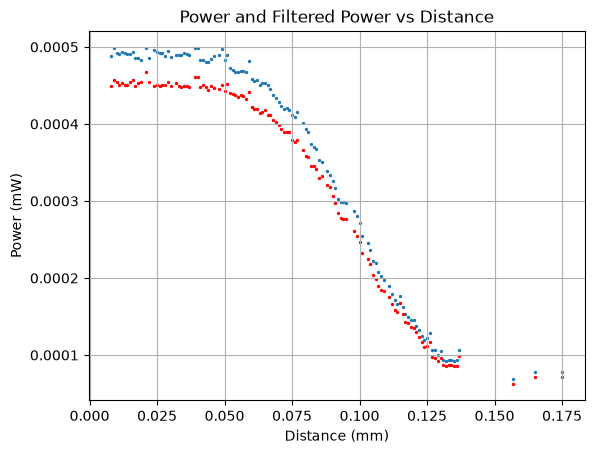

In [81]:
plt.scatter(df3_clean['Distance (mm)'], df3_clean['Power (mW)'],s=2)

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.scatter(df3_clean['Distance (mm)'], df3_clean['Power (mW)  filtered'],s=2, color='red')

plt.title('Power and Filtered Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

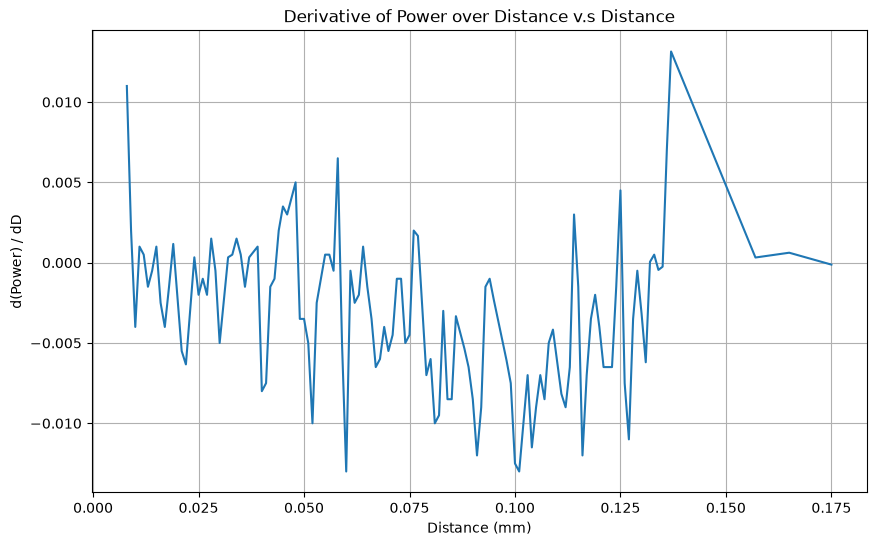

In [82]:
df3_clean = df3_clean.sort_values('Distance (mm)').reset_index(drop=True)

df3_clean['Derivative'] = np.gradient(df3_clean['Power (mW)'], df3_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df3_clean['Distance (mm)'], df3_clean['Derivative'])

plt.title('Derivative of Power over Distance v.s Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / dD')
plt.grid(True)

plt.show()

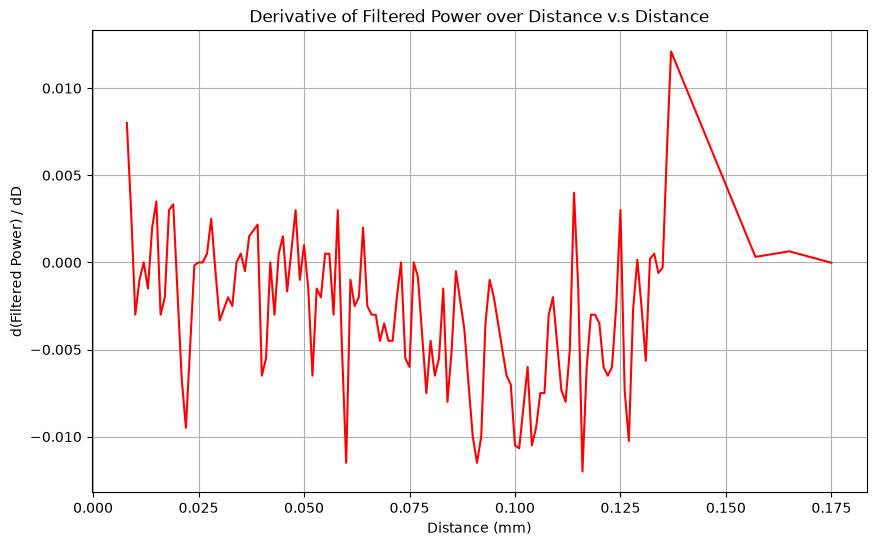

In [83]:
df3_clean_f = df3_clean_f.sort_values('Distance (mm)').reset_index(drop=True)

df3_clean_f['Derivative filtered'] = np.gradient(df3_clean_f['Power (mW) filtered'], df3_clean_f['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df3_clean_f['Distance (mm)'], df3_clean_f['Derivative filtered'], color='red')

plt.title('Derivative of Filtered Power over Distance v.s Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Filtered Power) / dD')
plt.grid(True)

plt.show()

In [84]:
df3_clean = df3.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df3_clean['Power (mW)'].rolling(window=window, center=True).median()
df3_clean = df3_clean.dropna().reset_index(drop=True)

x3 = df3_clean['Distance (mm)'].values
y3 = df3_clean['Power (mW)'].values

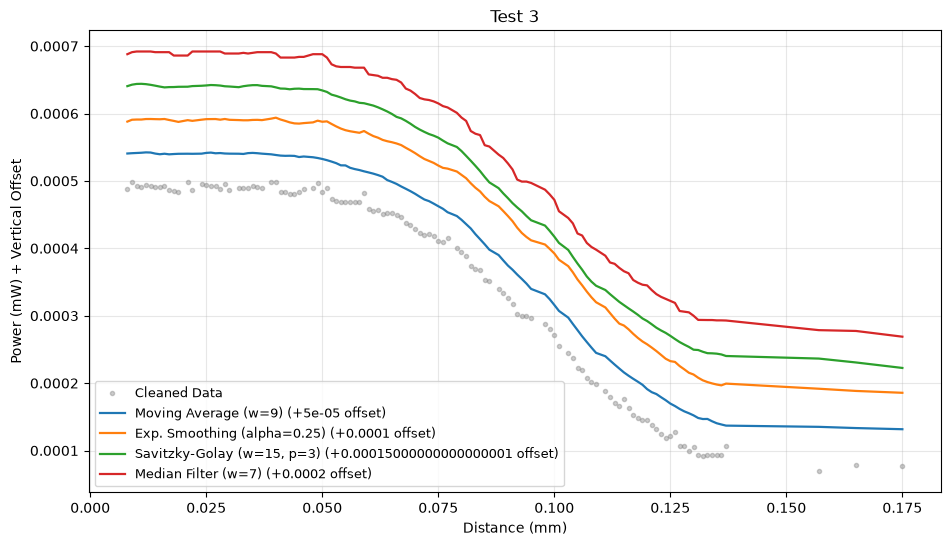

In [85]:
ma3 = moving_average_filter(y3, window=9)
es3, alpha3 = exponential_smooth(y3, alpha=0.25)
sg3 = sg_smooth(y3, window_length=15, polyorder=3)
med3 = median_smooth(y3, window=7)

scurve_methods_3 = {
    'Moving Average (w=9)': ma3,
    f'Exp. Smoothing (alpha={alpha3:.2f})': es3,
    'Savitzky-Golay (w=15, p=3)': sg3,
    'Median Filter (w=7)': med3,
}

plt.figure(figsize=(11, 6))
plt.plot(x3, y3, '.', color='grey', alpha=0.4, label='Cleaned Data')
offset_step = 0.00005 
for i, (name, sig) in enumerate(scurve_methods_3.items()):
    current_offset = (i + 1) * offset_step
    plt.plot(x3, sig + current_offset, linewidth=1.6, label=f"{name} (+{current_offset} offset)")

plt.title('Test 3')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW) + Vertical Offset')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [86]:
df3_clean_f = df3.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median_filtered = df3_clean_f['Power (mW) filtered'].rolling(window=window, center=True).median()
df3_clean_f = df3_clean_f.dropna().reset_index(drop=True)

x3_f = df3_clean_f['Distance (mm)'].values
y3_f = df3_clean_f['Power (mW) filtered'].values

KeyError: 'Power (mW) filtered'

In [88]:
ma3_f = moving_average_filter(y3_f, window=9)
es3_f, alpha3_f = exponential_smooth(y3_f, alpha=0.25)
sg3_f = sg_smooth(y3_f, window_length=15, polyorder=3)
med3_f = median_smooth(y3_f, window=7)

scurve_methods_3 = {
    'Moving Average (w=9)': ma3_f,
    f'Exp. Smoothing (alpha={alpha3_f:.2f})': es3_f,
    'Savitzky-Golay (w=15, p=3)': sg3_f,
    'Median Filter (w=7)': med3_f,
}

plt.figure(figsize=(11, 6))
plt.plot(x3_f, y3_f, '.', color='grey', alpha=0.4, label='Cleaned Data')
offset_step = 0.00005 
for i, (name, sig) in enumerate(scurve_methods_3.items()):
    current_offset = (i + 1) * offset_step
    plt.plot(x3_f, sig + current_offset, linewidth=1.6, label=f"{name} (+{current_offset} offset)")

plt.title('Test 3 filtered')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW) + Vertical Offset')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

NameError: name 'y3_f' is not defined

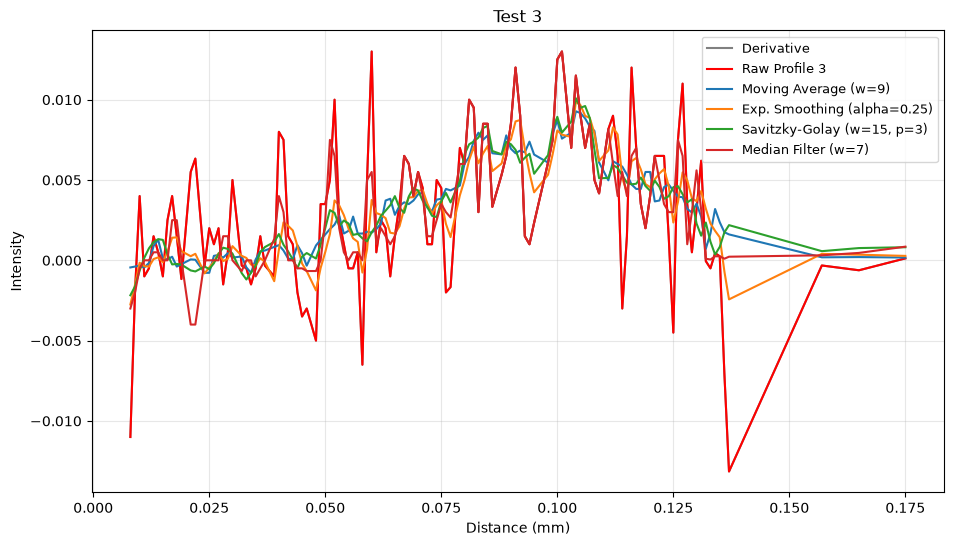

In [ ]:
raw_profile_3 = -np.gradient(y3, x3)

plt.figure(figsize=(11, 6))
plt.plot(x3, raw_profile_3, color='grey', label='Derivative')
plt.plot(x3, raw_profile_3, color='red', label='Raw Profile 3')
for name, sig in scurve_methods_3.items():
    prof = -np.gradient(sig, x3)
    plt.plot(x3, prof, label=name)
plt.title('Test 3')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

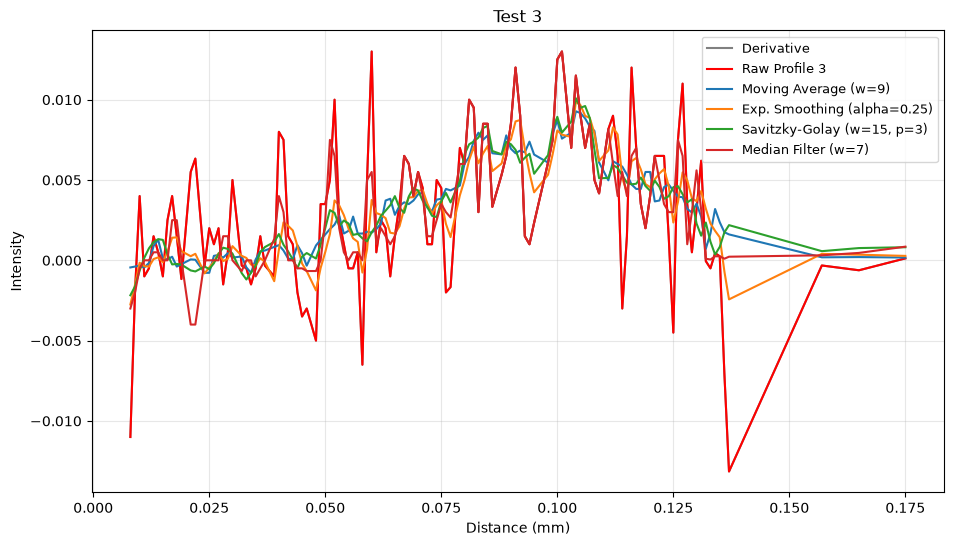

In [ ]:
raw_profile_3_f = -np.gradient(y3_f, x3_f)

plt.figure(figsize=(11, 6))
plt.plot(x3_f, raw_profile_3_f, color='grey', label='Derivative')
plt.plot(x3_f, raw_profile_3_f, color='red', label='Raw Profile 3')
for name, sig in scurve_methods_3.items():
    prof = -np.gradient(sig, x3_f)
    plt.plot(x3_f, prof, label=name)
plt.title('Test 3 filtered')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

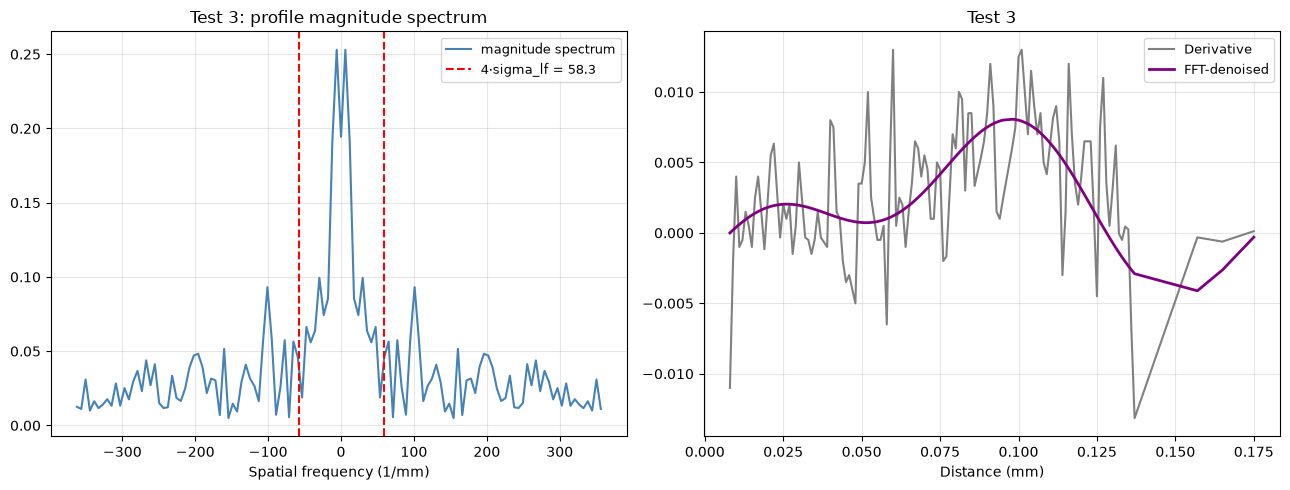

In [ ]:
fft_profile_3, sigma_lf_3, freqs_3, mag_3, lf_mask_3 = fft_denoise_profile(x3, raw_profile_3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_3, mag_3, color='steelblue', label='magnitude spectrum')
axes[0].axvline(4 * sigma_lf_3, color='red', linestyle='--', label=f'4·sigma_lf = {4*sigma_lf_3:.1f}')
axes[0].axvline(-4 * sigma_lf_3, color='red', linestyle='--')
axes[0].set_title('Test 3: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(x3, raw_profile_3, color='grey', label='Derivative')
axes[1].plot(x3, fft_profile_3, color='purple', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 3')
axes[1].set_xlabel('Distance (mm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

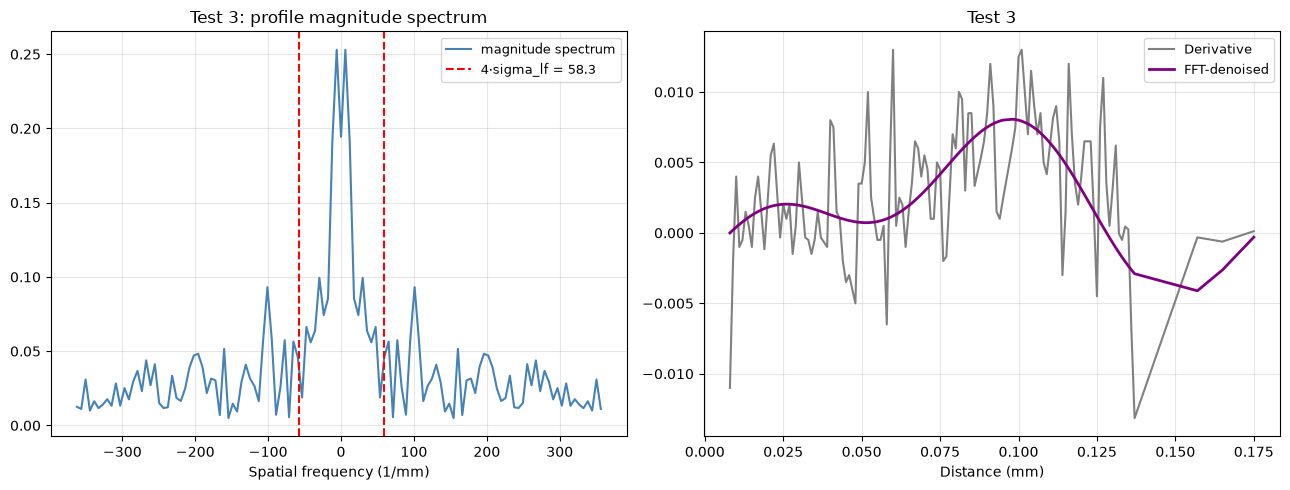

In [ ]:
fft_profile_3_f, sigma_lf_3_f, freqs_3_f, mag_3_f, lf_mask_3_f = fft_denoise_profile(x3_f, raw_profile_3_f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(freqs_3_f, mag_3_f, color='steelblue', label='magnitude spectrum')
axes[0].axvline(4 * sigma_lf_3_f, color='red', linestyle='--', label=f'4·sigma_lf = {4*sigma_lf_3_f:.1f}')
axes[0].axvline(-4 * sigma_lf_3_f, color='red', linestyle='--')
axes[0].set_title('Test 3: profile magnitude spectrum')
axes[0].set_xlabel('Spatial frequency (1/mm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(x3_f, raw_profile_3_f, color='grey', label='Derivative')
axes[1].plot(x3_f, fft_profile_3_f, color='purple', linewidth=2, label='FFT-denoised')
axes[1].set_title('Test 3 filtered')
axes[1].set_xlabel('Distance (mm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

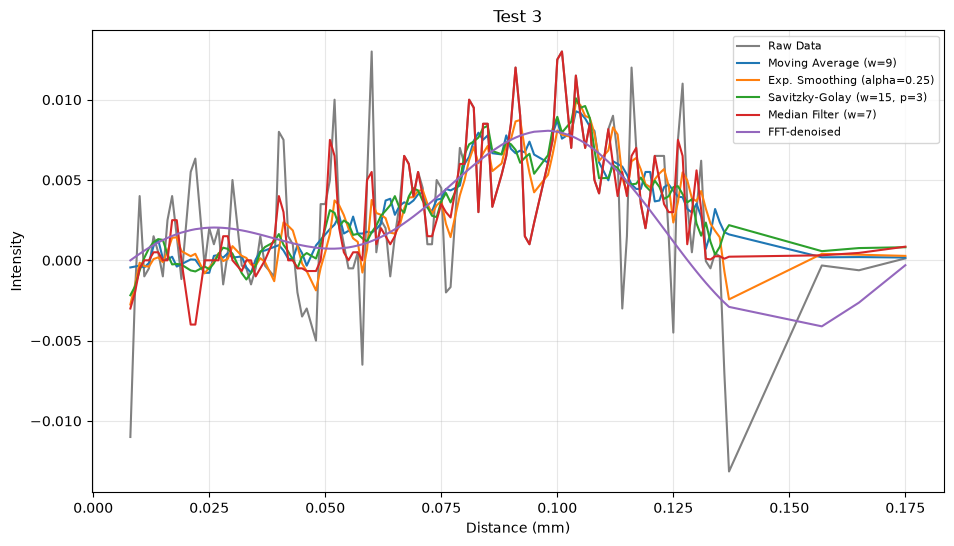

In [ ]:
all_profiles_3 = {name: -np.gradient(sig, x3) for name, sig in scurve_methods_3.items()}
all_profiles_3['FFT-denoised'] = fft_profile_3

plt.figure(figsize=(11, 6))
plt.plot(x3, raw_profile_3, color='grey', label='Raw Data')
for name, prof in all_profiles_3.items():
    plt.plot(x3, prof, label=name)
plt.title('Test 3')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
all_profiles_3_f = {name: -np.gradient(sig, x3_f) for name, sig in scurve_methods_3.items()}
all_profiles_3_f['FFT-denoised'] = fft_profile_3_f

plt.figure(figsize=(11, 6))
plt.plot(x3_f, raw_profile_3_f, color='grey', label='Raw Data')
for name, prof in all_profiles_3_f.items():
    plt.plot(x3_f, prof, label=name)
plt.title('Test 3 filtered')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

Method              w (1/e^2 radius, um)     center (mm)
Moving Average             46.61 +/-  1.52          0.0973
Exp. Smoothing             44.70 +/-  2.49          0.0999
Savitzky-Golay             45.62 +/-  2.00          0.0970
Median Filter              46.57 +/-  4.83          0.0972
FFT-denoised               30.53 +/-  1.50          0.0956


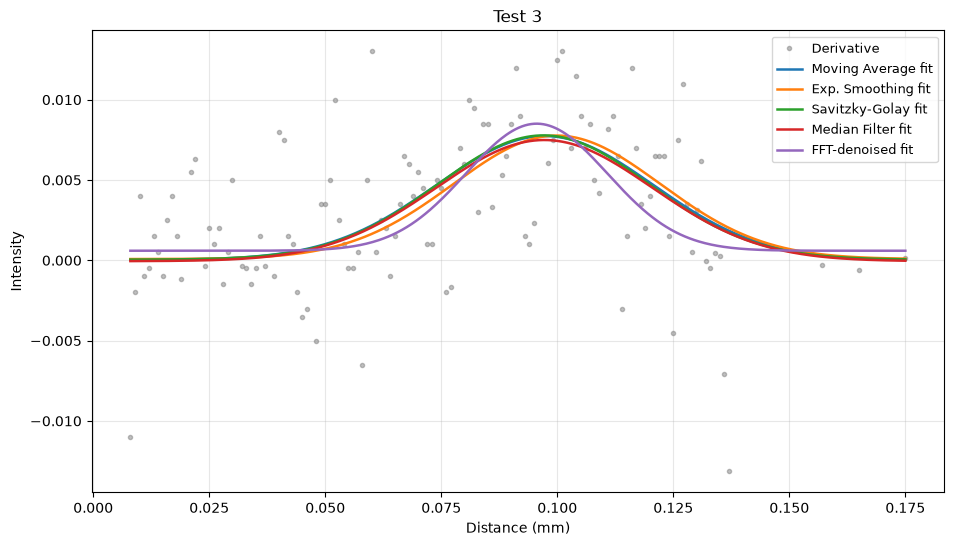

In [ ]:
profiles_3 = {
    'Moving Average': -np.gradient(ma3, x3),
    'Exp. Smoothing': -np.gradient(es3, x3),
    'Savitzky-Golay': -np.gradient(sg3, x3),
    'Median Filter': -np.gradient(med3, x3),
    'FFT-denoised': fft_profile_3,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_3 = {}
for name, prof in profiles_3.items():
    popt, perr = fit_beam_radius(x3, prof)
    A, x0, w, off = popt
    fits_3[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x3, raw_profile_3, '.', color='grey', alpha=0.5, label='Derivative')
x3_fine = np.linspace(x3.min(), x3.max(), 500)
for name, popt in fits_3.items():
    plt.plot(x3_fine, gaussian_beam(x3_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 3')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [87]:
profiles_3_f = {
    'Moving Average': -np.gradient(ma3_f, x3_f),
    'Exp. Smoothing': -np.gradient(es3_f, x3_f),
    'Savitzky-Golay': -np.gradient(sg3_f, x3_f),
    'Median Filter': -np.gradient(med3_f, x3_f),
    'FFT-denoised': fft_profile_3_f,
}

print(f"{'Method':16s}{'w (1/e^2 radius, um)':>24s}{'center (mm)':>16s}")
fits_3_f = {}
for name, prof in profiles_3_f.items():
    popt, perr = fit_beam_radius(x3_f, prof)
    A, x0, w, off = popt
    fits_3_f[name] = popt
    print(f"{name:16s}{abs(w)*1000:16.2f} +/- {perr[2]*1000:5.2f}{x0:16.4f}")

plt.figure(figsize=(11, 6))
plt.plot(x3_f, raw_profile_3_f, '.', color='grey', alpha=0.5, label='Derivative')
x3_fine = np.linspace(x3_f.min(), x3_f.max(), 500)
for name, popt in fits_3_f.items():
    plt.plot(x3_fine, gaussian_beam(x3_fine, *popt), linewidth=1.8, label=f'{name} fit')
plt.title('Test 3')
plt.xlabel('Distance (mm)')
plt.ylabel('Intensity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

NameError: name 'ma3_f' is not defined